In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import jenkspy
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import confusion_matrix, classification_report


In [162]:
# 1. Load your dataset
Flu_weather = pd.read_csv('NY_Flu_Weather_Final_Weekly.csv')

Flu_weather.head()

,County,Year,Month,Season,Region,Week,Week Ending Date,Disease,Infected,Avg household size,...,Latitude,Longitude,Prob_infected,County_Density,Ending Date,avg_temp_prior_week,avg_humidity_prior_week,avg_dew_point_prior_week,avg_precip_prior_week,avg_wind_speed_prior_week
0,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_A,4,2.3,...,42.601,-73.977,0.000013,582.162575,2009-10-10,52.136235,75.422893,44.082307,0.082677,11.513748
1,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_B,0,2.3,...,42.601,-73.977,0.000000,582.162575,2009-10-10,52.136235,75.422893,44.082307,0.082677,11.513748
2,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_UNSPECIFIED,0,2.3,...,42.601,-73.977,0.000000,582.162575,2009-10-10,52.136235,75.422893,44.082307,0.082677,11.513748
3,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,41,10/17/2009,INFLUENZA_A,11,2.3,...,42.601,-73.977,0.000036,582.162575,2009-10-17,39.730165,68.109046,29.425700,0.042745,7.608064
4,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,41,10/17/2009,INFLUENZA_B,0,2.3,...,42.601,-73.977,0.000000,582.162575,2009-10-17,39.730165,68.109046,29.425700,0.042745,7.608064


In [163]:
def calculate_rsi(df):
    """
    Calculates the Resource Strain Index (RSI) based on weather stress factors.
    Assumes df contains: 'avg_temp', 'avg_humidity', and 'avg_dewpoint'
    """
    
    # 1. Define the 'Ideal' Maxima from your dataset 
    # (These should represent the warmest/most humid points in your data)
    T_max = df['avg_temp_prior_week'].max()
    H_max = df['avg_humidity_prior_week'].max()
    D_max = df['avg_dew_point_prior_week'].max()

    # 2. Calculate the Inversions
    # Lower temp/humidity/dewpoint = Higher Stress Score
    df['temp_stress'] = T_max - df['avg_temp_prior_week']
    df['hum_stress'] = H_max - df['avg_humidity_prior_week']
    df['dew_stress'] = D_max - df['avg_dew_point_prior_week']

    # 3. Aggregate into a single Index (RSI)
    # We take the mean of the three stress components
    df['RSI'] = (df['temp_stress'] + df['hum_stress'] + df['dew_stress']) / 3

    # Clean up intermediate columns to keep the dataframe lean
    df = df.drop(columns=['temp_stress', 'hum_stress', 'dew_stress'])
    
    return df

# Apply to your main dataframe
Flu_weather = calculate_rsi(Flu_weather)

print(f"RSI Range: {Flu_weather['RSI'].min():.2f} to {Flu_weather['RSI'].max():.2f}")

RSI Range: 4.36 to 57.66


In [164]:
#More feature engineering

def engineer_flu_features(df):
    # Sort by County and Date to ensure windows/lags are chronological
    # Assuming your dataframe has 'County' and 'Ending Date' columns
    df = df.sort_values(['County', 'Ending Date'])
    
    # --- 1. Cumulative Exposure (Sustained Environment) ---
    # We use a 4-week rolling mean to capture the 'Season' effect
    df['RSI_Sustained'] = df.groupby('County')['RSI'].transform(
        lambda x: x.rolling(window=4, min_periods=1).mean()
    )
    
    # --- 2. Rate of Change (The Shock) ---
    # Calculate how much the temperature dropped compared to last week
    # A negative value means it got colder (potential immune stress)
    df['Temp_Change_Velocity'] = df.groupby('County')['avg_temp_prior_week'].diff()
    
    # --- 3. Risk Windows (Based on your Charts) ---
    # Identifying the from EDA' risk windows where infection rates spike
    # Temp window: 15 to 35 | Dew Point window: 10 to 30
    df['In_Risk_Window'] = (
        (df['avg_temp_prior_week'].between(15, 35)) & 
        (df['avg_dew_point_prior_week'].between(10, 30))
    ).astype(int)
    
    # --- 4. RSI Volatility ---
    # High variance in weather can be more stressful than constant cold
    df['RSI_Volatility'] = df.groupby('County')['RSI'].transform(
        lambda x: x.rolling(window=3, min_periods=1).std()
    )
    
    return df

# Apply the function
Flu_weather = engineer_flu_features(Flu_weather)

# For Volatility (using 0 because there is no volatility in a single data point)
Flu_weather['Temp_Change_Velocity'] = Flu_weather.groupby('County')['Temp_Change_Velocity'].transform(lambda x: x.fillna(0))
Flu_weather['RSI_Volatility'] = Flu_weather.groupby('County')['RSI_Volatility'].transform(lambda x: x.fillna(0))

In [165]:
print(Flu_weather[['RSI', 'RSI_Sustained', 'Temp_Change_Velocity', 'In_Risk_Window', 'RSI_Volatility']].head())

         RSI  RSI_Sustained  Temp_Change_Velocity  In_Risk_Window  \
0  18.447291      18.447291               0.00000               0   
1  18.447291      18.447291               0.00000               0   
2  18.447291      18.447291               0.00000               0   
3  29.906132      21.312001             -12.40607               0   
4  29.906132      24.176712               0.00000               0   

   RSI_Volatility  
0        0.000000  
1        0.000000  
2        0.000000  
3        6.615765  
4        6.615765  


In [166]:
#  Existing Split
X = Flu_weather[['RSI', 'avg_precip_prior_week', 'avg_wind_speed_prior_week', 'RSI_Sustained', 'Temp_Change_Velocity', 'In_Risk_Window', 'RSI_Volatility']]
y = Flu_weather['Prob_infected']
y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 2. Define the Hybrid Groups
pca_features = ['RSI', 'RSI_Sustained', 'RSI_Volatility', 'avg_precip_prior_week', 'avg_wind_speed_prior_week']
raw_features = ['Temp_Change_Velocity', 'In_Risk_Window']

# 3. Scaling (Uses your X_train and X_test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[pca_features])
X_test_scaled = scaler.transform(X_test[pca_features])

# 4. PCA (Uses the scaled versions of your split)
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 5. Re-combining with Raw Features
# We use .index to ensure the PCA rows line up with the original Split rows
pca_cols = [f'PC{i+1}' for i in range(4)]
X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train.index)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_cols, index=X_test.index)

X_train_hybrid = pd.concat([X_train_pca_df, X_train[raw_features]], axis=1)
X_test_hybrid = pd.concat([X_test_pca_df, X_test[raw_features]], axis=1)


In [ ]:
#Resampling

def rsi_undersample_fixed(X_hybrid, y_train, rsi_series, keep_fraction=0.20):
    """
    X_hybrid: The dataframe with PCA components and Raw features
    y_train: The log-transformed target
    rsi_series: The original RSI column from un-PCA'd X_train
    """
    
    # 1. Calculate threshold (Median of the RSI)
    threshold = rsi_series.median()
    
    # 2. Identify indices based on the RSI series
    # These indices match the index of X_hybrid because they both came from X_train
    weak_indices = rsi_series[rsi_series < threshold].index
    strong_indices = rsi_series[rsi_series >= threshold].index
    
    # 3. Randomly select which 'Weak' indices to keep
    n_to_keep = int(len(weak_indices) * keep_fraction)
    sampled_weak_indices = np.random.choice(weak_indices, size=n_to_keep, replace=False)
    
    # 4. Combine with ALL strong indices
    final_indices = np.concatenate([strong_indices, sampled_weak_indices])
    
    # 5. Use .loc to pull these rows from the hybrid features and target
    X_resampled = X_hybrid.loc[final_indices].sample(frac=1, random_state=42) # Shuffle
    y_resampled = y_train.loc[X_resampled.index] # Ensure target matches shuffled features
    
    print(f"RSI Threshold used: {threshold:.4f}")
    print(f"Kept {len(strong_indices)} strong weeks and {len(sampled_weak_indices)} weak weeks.")
    
    return X_resampled, y_resampled

# --- CALLING THE FUNCTION ---
# Pass the original 'RSI' series specifically so the function can find it
X_train_balanced, y_train_balanced = rsi_undersample_fixed(
    X_train_hybrid, 
    y_train_log, 
    rsi_series=X_train['RSI'], 
    keep_fraction=0.20
)

RSI Threshold used: 29.0783
Kept 23139 strong weeks and 4627 weak weeks.


In [170]:
# 3. The Ensemble Method: Gradient Boosting
# This is the 'Brain' that learns the weather-to-infection patterns
model_gb = GradientBoostingRegressor(
    n_estimators=100,    #Lower number of trees to prevent overfitting with limited features
    learning_rate=0.05, 
    max_depth=5, 
    loss='quantile',  #Using MAE to penalize underestimation more than MSE
    random_state=42, 
)


model_gb.fit(X_train_balanced, y_train_balanced)



# Try lagging different features to see if it improves the model
# Also add a loss function that penalizes underestimation more than overestimation, since underestimating risk is more dangerous in this context.
# Can also over sample the high-risk weeks to give the model more examples of those critical scenarios.
# In presentation explain how we come up with categories

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'quantile'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft chil

In [171]:
# 1. Get predictions on your training set
train_preds = model_gb.predict(X_train_balanced) 

breaks = jenkspy.jenks_breaks(train_preds, n_classes=4)

print(f"Model-Derived Thresholds: {breaks}")


Model-Derived Thresholds: [np.float64(-4.896811068348792e-06), np.float64(4.6789839008145974e-05), np.float64(0.00015429379703667205), np.float64(0.00029457340481649696), np.float64(0.0008872216130920738)]


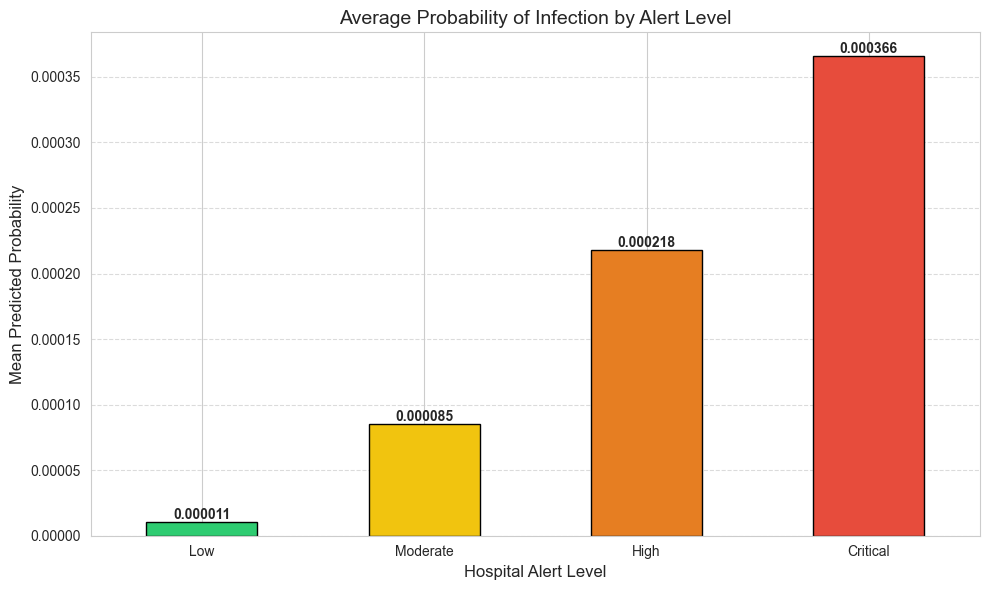

In [172]:
y_pred_probs = model_gb.predict(X_test_hybrid)  # Get predicted log probabilities
y_test_probs = np.expm1(y_test_log)  # Convert back to original scale for comparison

# Define the results DataFrame
# We align the actual values and predicted values side-by-side
results = pd.DataFrame({
    'actual_prob': y_test_probs,    # The real infection data from your test set
    'pred_prob': y_pred_probs  # What your model thinks the infection risk is
})


# 1. Define your specific thresholds and labels
# Note: I replaced the negative min with 0 for cleaner reporting
breaks = [0, 4.67898e-05, 0.000154293, 0.0002945734, 0.0008872]
labels = ['Low', 'Moderate', 'High', 'Critical']

# 2. Assign each prediction to a bin (Assuming 'results' is your DF)
# 'include_lowest=True' ensures the 0 value is caught in the first bin
results['alert_level'] = pd.cut(results['pred_prob'], bins=breaks, labels=labels, include_lowest=True)

# 3. Calculate the average probability for each bin
bin_stats = results.groupby('alert_level')['pred_prob'].mean()

# 4. Create the bar chart
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'] # Green, Yellow, Orange, Red
plt.figure(figsize=(10, 6))
bin_stats.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Average Probability of Infection by Alert Level', fontsize=14)
plt.xlabel('Hospital Alert Level', fontsize=12)
plt.ylabel('Mean Predicted Probability', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for i, v in enumerate(bin_stats):
    plt.text(i, v, f"{v:.6f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

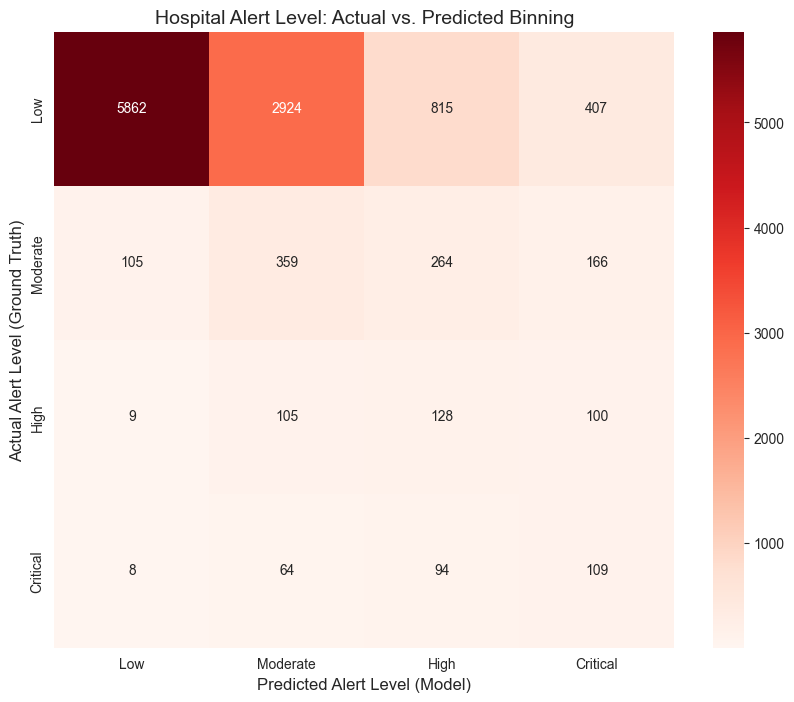

Classification Report for Hospital Bins:
              precision    recall  f1-score   support

         Low       0.14      0.40      0.21       275
    Moderate       0.10      0.37      0.16       342
        High       0.98      0.59      0.73     10008
    Critical       0.10      0.40      0.17       894

    accuracy                           0.56     11519
   macro avg       0.33      0.44      0.32     11519
weighted avg       0.87      0.56      0.66     11519



In [173]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Apply the binning to the ACTUAL data using the same breaks
results['actual_alert_level'] = pd.cut(
    results['actual_prob'], 
    bins=breaks, 
    labels=labels, 
    include_lowest=True
)

# 2. Drop any rows where actual_prob was outside the breaks range (NaNs)
# This prevents the 'str vs float' comparison error during the matrix generation
results_clean = results.dropna(subset=['alert_level', 'actual_alert_level'])

# 3. Generate the Confusion Matrix
# We explicitly set 'labels=labels' to ensure the order is Low -> Moderate -> High -> Critical
cm = confusion_matrix(results_clean['actual_alert_level'], results_clean['alert_level'], labels=labels)

# 4. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=labels, yticklabels=labels)

plt.title('Hospital Alert Level: Actual vs. Predicted Binning', fontsize=14)
plt.xlabel('Predicted Alert Level (Model)', fontsize=12)
plt.ylabel('Actual Alert Level (Ground Truth)', fontsize=12)
plt.show()

# 5. Summary Statistics
print("Classification Report for Hospital Bins:")
print(classification_report(results_clean['actual_alert_level'], results_clean['alert_level'], target_names=labels))

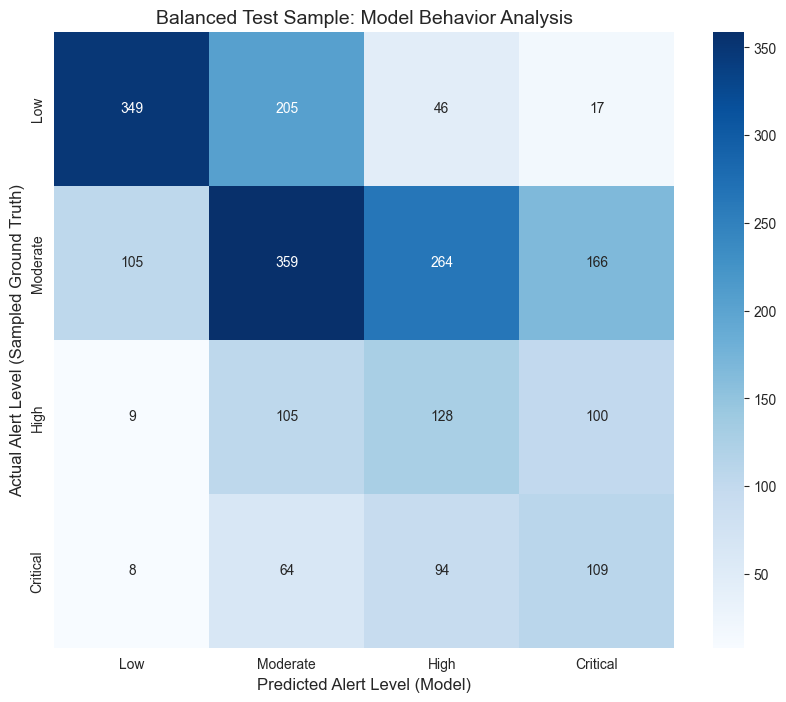

Sampled Classification Report (Balanced View):
              precision    recall  f1-score   support

         Low       0.28      0.40      0.33       275
    Moderate       0.24      0.37      0.29       342
        High       0.74      0.57      0.64       617
    Critical       0.49      0.40      0.44       894

    accuracy                           0.44      2128
   macro avg       0.44      0.43      0.43      2128
weighted avg       0.50      0.44      0.46      2128



In [174]:
# 1. Separate the results by their ACTUAL labels
# (We use results_clean since you already handled NaNs there)
df_critical = results_clean[results_clean['actual_alert_level'] == 'Critical']
df_high = results_clean[results_clean['actual_alert_level'] == 'High']
df_moderate = results_clean[results_clean['actual_alert_level'] == 'Moderate']
df_low = results_clean[results_clean['actual_alert_level'] == 'Low']

# 2. Determine a sample size
# To see a clear 'scientific' view, let's match the number of Lows to the number of Highs/Criticals
# This removes the 5000+ Lows that squeeze your heatmap
sample_size = len(df_high) + len(df_critical) 

# 3. Create the balanced subset
# We take all the rare cases and a 'human-readable' amount of the common ones
results_sampled = pd.concat([
    df_critical,
    df_high,
    df_moderate,
    df_low.sample(n=min(len(df_low), sample_size), random_state=42)
])

# 4. Generate the Sampled Confusion Matrix
cm_sampled = confusion_matrix(
    results_sampled['actual_alert_level'], 
    results_sampled['alert_level'], 
    labels=labels
)

# 5. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_sampled, annot=True, fmt='d', cmap='Blues', # Use Blue to distinguish from the 'Real' report
            xticklabels=labels, yticklabels=labels)

plt.title('Balanced Test Sample: Model Behavior Analysis', fontsize=14)
plt.xlabel('Predicted Alert Level (Model)', fontsize=12)
plt.ylabel('Actual Alert Level (Sampled Ground Truth)', fontsize=12)
plt.show()

# 6. Summary Statistics for the Sample
print("Sampled Classification Report (Balanced View):")
print(classification_report(
    results_sampled['actual_alert_level'], 
    results_sampled['alert_level'], 
    target_names=labels
))

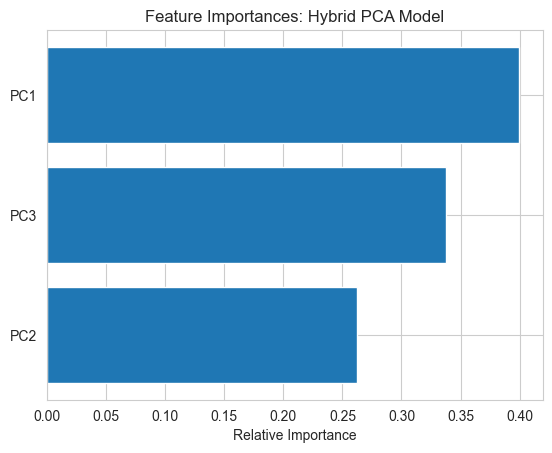

In [175]:
import matplotlib.pyplot as plt

# Get feature importances from your trained model
importances = model.feature_importances_
feature_names = X_train_hybrid.columns

# Sort and Plot
indices = np.argsort(importances)
plt.title('Feature Importances: Hybrid PCA Model')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()